In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv,find_dotenv
from langchain_groq import ChatGroq


In [3]:
load_dotenv(find_dotenv())  # load .env file

True

In [4]:

model = ChatGroq(model_name="openai/gpt-oss-20b", temperature=0.7)

In [5]:
class BlogState(TypedDict):

    title: str
    outline: str
    content: str

In [6]:
def create_outline(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # call llm gen outline
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state

In [7]:
def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title - {title} using the follwing outline \n {outline}'

    content = model.invoke(prompt).content

    state['content'] = content

    return state

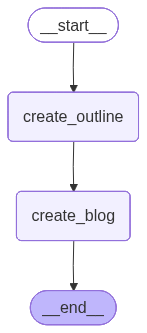

In [ ]:
graph = StateGraph(BlogState)

# nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()

In [9]:
intial_state = {'title': 'Rise of AI in India'}

final_state = workflow.invoke(intial_state)

print(final_state)

{'title': 'Rise of AI in India', 'outline': '## Blog Outline  \n**Title:** *Rise of AI in India: From Start‑ups to Smart Nation*  \n\n---\n\n### 1. Introduction (≈150–200 words)  \n- **Hook:** Quick anecdote or statistic (e.g., India’s AI market projected to hit ₹3.5\u202ftrn by 2026).  \n- **Scope:** Why AI matters to India’s economy, society, and global standing.  \n- **Purpose:** Outline what readers will learn (history, current landscape, key players, challenges, future).\n\n---\n\n### 2. A Brief History of AI in India  \n| Era | Key Milestones | Impact |\n|-----|----------------|--------|\n| **Early 1990s – 2000s** | • First AI research groups (e.g., IITs, IISc).<br>• Government’s “Artificial Intelligence for All” vision (2009). | Foundation for academia‑industry collaboration. |\n| **2010–2015** | • Launch of the *National AI Strategy* (2018, but groundwork started earlier).<br>• Rise of AI start‑ups (e.g., Haptik, SigTuple). | Increased funding and talent pool. |\n| **2016–2020*

In [10]:
print(final_state['outline'])

## Blog Outline  
**Title:** *Rise of AI in India: From Start‑ups to Smart Nation*  

---

### 1. Introduction (≈150–200 words)  
- **Hook:** Quick anecdote or statistic (e.g., India’s AI market projected to hit ₹3.5 trn by 2026).  
- **Scope:** Why AI matters to India’s economy, society, and global standing.  
- **Purpose:** Outline what readers will learn (history, current landscape, key players, challenges, future).

---

### 2. A Brief History of AI in India  
| Era | Key Milestones | Impact |
|-----|----------------|--------|
| **Early 1990s – 2000s** | • First AI research groups (e.g., IITs, IISc).<br>• Government’s “Artificial Intelligence for All” vision (2009). | Foundation for academia‑industry collaboration. |
| **2010–2015** | • Launch of the *National AI Strategy* (2018, but groundwork started earlier).<br>• Rise of AI start‑ups (e.g., Haptik, SigTuple). | Increased funding and talent pool. |
| **2016–2020** | • AI in public sector pilots (e.g., AI for Disaster Management)

In [11]:
print(final_state['content'])

# Rise of AI in India: From Start‑ups to Smart Nation  

*Word‑count: ~3,580*  

---

## 1. Introduction (≈180 words)

Picture a bustling Delhi market where a smartphone on a vendor’s wrist predicts the next price surge of mangoes, or an AI‑powered chatbot that triages a COVID‑19 patient in rural Rajasthan with the same speed as a doctor. These scenes are not science‑fiction; they are the new reality of an India that is turning artificial intelligence (AI) from a buzzword into a nation‑wide catalyst.  

According to a recent report by *McKinsey & Company*, India’s AI market is projected to hit **₹3.5 trillion** (≈$44 billion) by 2026, driven by a surge in digital services, e‑commerce, and public‑sector digitisation. AI is no longer a niche technology—it is a strategic lever for economic growth, inclusive development, and global competitiveness.  

In this blog we will:

1. Trace the evolution of AI in India from its humble academic roots to today’s vibrant ecosystem.  
2. Examine the g